In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/content/sample_data/DataCoSupplyChainDataset.csv', encoding='unicode_escape')

# Check shape
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')

Rows    : 180,519
Columns : 53


In [ ]:
print('=== All Column Names ===')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:02d}. {col}')

=== All Column Names ===
  01. Type
  02. Days for shipping (real)
  03. Days for shipment (scheduled)
  04. Benefit per order
  05. Sales per customer
  06. Delivery Status
  07. Late_delivery_risk
  08. Category Id
  09. Category Name
  10. Customer City
  11. Customer Country
  12. Customer Email
  13. Customer Fname
  14. Customer Id
  15. Customer Lname
  16. Customer Password
  17. Customer Segment
  18. Customer State
  19. Customer Street
  20. Customer Zipcode
  21. Department Id
  22. Department Name
  23. Latitude
  24. Longitude
  25. Market
  26. Order City
  27. Order Country
  28. Order Customer Id
  29. order date (DateOrders)
  30. Order Id
  31. Order Item Cardprod Id
  32. Order Item Discount
  33. Order Item Discount Rate
  34. Order Item Id
  35. Order Item Product Price
  36. Order Item Profit Ratio
  37. Order Item Quantity
  38. Sales
  39. Order Item Total
  40. Order Profit Per Order
  41. Order Region
  42. Order State
  43. Order Status
  44. Order Zipcode
 

In [ ]:
print('=== Null Values ===')
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': nulls, 'Null %': nulls_pct})
print(null_df[null_df['Null Count'] > 0])

print('\n=== Data Types ===')
print(df.dtypes)

=== Null Values ===
                     Null Count  Null %
Customer Lname                8    0.00
Customer Zipcode              3    0.00
Order Zipcode            155679   86.24
Product Description      180519  100.00

=== Data Types ===
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street       

In [ ]:
# 1. Drop useless columns
drop_cols = [
    'Customer Email',
    'Customer Password',
    'Customer Street',
    'Customer Zipcode',
    'Customer Lname',
    'Order Zipcode',
    'Product Description',
    'Product Image',
    'Latitude',
    'Longitude'
]
df.drop(columns=drop_cols, inplace=True)
print(f'✅ Dropped {len(drop_cols)} useless columns')
print(f'   Remaining columns: {df.shape[1]}')

✅ Dropped 10 useless columns
   Remaining columns: 43


In [ ]:
# 2. Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'✅ Duplicates removed: {before - len(df):,}')
print(f'   Remaining rows: {len(df):,}')

✅ Duplicates removed: 0
   Remaining rows: 180,519


In [ ]:
# 3. Convert date columns to datetime
df['order date (DateOrders)']    = pd.to_datetime(df['order date (DateOrders)'],   errors='coerce')
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')

print('✅ Dates converted')
print(df[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes)

✅ Dates converted
order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object


In [ ]:
# 4. Standardize text columns (strip spaces, title case)
text_cols = [
    'Delivery Status', 'Shipping Mode', 'Market',
    'Order Region', 'Order Country', 'Customer Segment',
    'Category Name', 'Department Name', 'Product Name'
]
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print('✅ Text columns standardized')

✅ Text columns standardized


In [ ]:
# 5. Final check
print(f'\n=== After Cleaning ===')
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Nulls   : {df.isnull().sum().sum()}')


=== After Cleaning ===
Rows    : 180,519
Columns : 43
Nulls   : 0


In [ ]:
# 1. Delivery Delay Days (positive = late, negative = early)
df['delivery_delay_days'] = (
    df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
)
print('✅ delivery_delay_days created')
print(df['delivery_delay_days'].describe())

✅ delivery_delay_days created
count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delivery_delay_days, dtype: float64


In [ ]:
# 2. Delay Flag (1 = late, 0 = on time)
df['delay_flag'] = (df['delivery_delay_days'] > 0).astype(int)
print('✅ delay_flag created')
print(df['delay_flag'].value_counts())

✅ delay_flag created
delay_flag
1    103400
0     77119
Name: count, dtype: int64


In [ ]:
# 3. Delay Category
def categorize_delay(days):
    if days <= 0:
        return 'On Time'
    elif days <= 2:
        return 'Minor Delay'
    elif days <= 5:
        return 'Moderate Delay'
    else:
        return 'Severe Delay'

df['delay_category'] = df['delivery_delay_days'].apply(categorize_delay)
print('✅ delay_category created')
print(df['delay_category'].value_counts())

✅ delay_category created
delay_category
Minor Delay       89365
On Time           77119
Moderate Delay    14035
Name: count, dtype: int64


In [ ]:
# 4. Profit Margin %
df['profit_margin'] = (
    (df['Benefit per order'] / df['Sales']) * 100
).round(2)
print('✅ profit_margin created')
print(df['profit_margin'].describe())

✅ profit_margin created
count    180519.000000
mean         10.832485
std          42.059324
min        -275.000000
25%           6.220000
50%          24.250000
75%          33.600000
max          50.040000
Name: profit_margin, dtype: float64


In [ ]:
# 5. Shipping Efficiency (scheduled vs actual)
df['shipping_efficiency'] = (
    df['Days for shipment (scheduled)'] /
    df['Days for shipping (real)'].replace(0, np.nan)
).round(2)
print('✅ shipping_efficiency created')

✅ shipping_efficiency created


In [ ]:
# 6. Time columns for trend analysis
df['order_month']      = df['order date (DateOrders)'].dt.month
df['order_month_name'] = df['order date (DateOrders)'].dt.strftime('%B')
df['order_year']       = df['order date (DateOrders)'].dt.year
df['order_quarter']    = df['order date (DateOrders)'].dt.quarter
print('✅ Time columns created')
print(df['order_year'].value_counts().sort_index())

✅ Time columns created
order_year
2015    62650
2016    62550
2017    53196
2018     2123
Name: count, dtype: int64


In [ ]:
# 7. Final check — all new columns
new_cols = [
    'delivery_delay_days', 'delay_flag', 'delay_category',
    'profit_margin', 'shipping_efficiency',
    'order_month', 'order_month_name', 'order_year', 'order_quarter'
]
print('=== New Columns Preview ===')
print(df[new_cols].head(10))

=== New Columns Preview ===
   delivery_delay_days  delay_flag delay_category  profit_margin  \
0                   -1           0        On Time          27.84   
1                    1           1    Minor Delay         -76.00   
2                    0           0        On Time         -75.60   
3                   -1           0        On Time           6.97   
4                   -2           0        On Time          40.95   
5                    2           1    Minor Delay           5.67   
6                    1           1    Minor Delay          29.04   
7                    1           1    Minor Delay          20.88   
8                    1           1    Minor Delay          40.80   
9                    1           1    Minor Delay          40.32   

   shipping_efficiency  order_month order_month_name  order_year  \
0                 1.33            1          January        2018   
1                 0.80            1          January        2018   
2                 1

In [ ]:
# 1. FACT TABLE — core transactional data
fact_orders = df[[
    'Order Id',
    'Order Customer Id',
    'Product Card Id',
    'Order Item Id',
    'order date (DateOrders)',
    'shipping date (DateOrders)',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'delivery_delay_days',
    'delay_flag',
    'delay_category',
    'Delivery Status',
    'Late_delivery_risk',
    'Shipping Mode',
    'Order Item Quantity',
    'Sales',
    'Benefit per order',
    'Order Item Total',
    'Order Profit Per Order',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'profit_margin',
    'shipping_efficiency',
    'order_month',
    'order_month_name',
    'order_year',
    'order_quarter',
    'Order Status',
    'Order Region',
    'Order Country',
    'Market'
]].copy()

print(f'✅ fact_orders → Rows: {fact_orders.shape[0]:,} | Columns: {fact_orders.shape[1]}')

✅ fact_orders → Rows: 180,519 | Columns: 33


In [ ]:
# 2. DIM CUSTOMERS
dim_customers = df[[
    'Customer Id',
    'Customer Fname',
    'Customer Segment',
    'Customer City',
    'Customer State',
    'Customer Country'
]].drop_duplicates(subset='Customer Id').copy()

print(f'✅ dim_customers → Rows: {dim_customers.shape[0]:,} | Columns: {dim_customers.shape[1]}')

✅ dim_customers → Rows: 20,652 | Columns: 6


In [ ]:
# 3. DIM PRODUCTS
dim_products = df[[
    'Product Card Id',
    'Product Name',
    'Product Price',
    'Product Status',
    'Category Id',
    'Category Name',
    'Department Id',
    'Department Name'
]].drop_duplicates(subset='Product Card Id').copy()

print(f'✅ dim_products → Rows: {dim_products.shape[0]:,} | Columns: {dim_products.shape[1]}')

✅ dim_products → Rows: 118 | Columns: 8


In [ ]:
# 4. DIM SHIPPING
dim_shipping = df[[
    'Order Id',
    'Shipping Mode',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'delivery_delay_days',
    'delay_flag',
    'delay_category',
    'Delivery Status',
    'Late_delivery_risk'
]].drop_duplicates(subset='Order Id').copy()

print(f'✅ dim_shipping → Rows: {dim_shipping.shape[0]:,} | Columns: {dim_shipping.shape[1]}')

✅ dim_shipping → Rows: 65,752 | Columns: 9


In [ ]:
# 5. DIM GEOGRAPHY
dim_geography = df[[
    'Order Region',
    'Order Country',
    'Order City',
    'Order State',
    'Market'
]].drop_duplicates().copy()

print(f'✅ dim_geography → Rows: {dim_geography.shape[0]:,} | Columns: {dim_geography.shape[1]}')

✅ dim_geography → Rows: 3,772 | Columns: 5


In [ ]:
# Final summary
print('\n=== Tables Created ===')
print(f'  fact_orders   : {fact_orders.shape}')
print(f'  dim_customers : {dim_customers.shape}')
print(f'  dim_products  : {dim_products.shape}')
print(f'  dim_shipping  : {dim_shipping.shape}')
print(f'  dim_geography : {dim_geography.shape}')


=== Tables Created ===
  fact_orders   : (180519, 33)
  dim_customers : (20652, 6)
  dim_products  : (118, 8)
  dim_shipping  : (65752, 9)
  dim_geography : (3772, 5)


In [ ]:
import os

# Create cleaned folder if not exists
os.makedirs('data/cleaned', exist_ok=True)

# Export all tables
fact_orders.to_csv('data/cleaned/fact_orders.csv', index=False)
dim_customers.to_csv('data/cleaned/dim_customers.csv', index=False)
dim_products.to_csv('data/cleaned/dim_products.csv', index=False)
dim_shipping.to_csv('data/cleaned/dim_shipping.csv', index=False)
dim_geography.to_csv('data/cleaned/dim_geography.csv', index=False)

print('✅ All tables exported to data/cleaned/')
print('\n=== Files Saved ===')
for f in os.listdir('data/cleaned'):
    size = os.path.getsize(f'data/cleaned/{f}') / 1024
    print(f'  {f:35s} → {size:,.1f} KB')

✅ All tables exported to data/cleaned/

=== Files Saved ===
  dim_products.csv                    → 9.0 KB
  fact_orders.csv                     → 47,006.7 KB
  dim_geography.csv                   → 192.9 KB
  dim_shipping.csv                    → 3,586.3 KB
  dim_customers.csv                   → 867.8 KB


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('visuals', exist_ok=True)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

In [ ]:
# 1. Overall KPIs
print('=== Business KPIs ===')
print(f'  Total Orders     : {fact_orders["Order Id"].nunique():,}')
print(f'  Total Sales      : ${fact_orders["Sales"].sum():,.2f}')
print(f'  Total Profit     : ${fact_orders["Benefit per order"].sum():,.2f}')
print(f'  Avg Delay Days   : {fact_orders["delivery_delay_days"].mean():.2f}')
print(f'  Late Orders %    : {fact_orders["delay_flag"].mean()*100:.1f}%')
print(f'  On Time Orders % : {(1 - fact_orders["delay_flag"].mean())*100:.1f}%')
print(f'  Avg Profit Margin: {fact_orders["profit_margin"].mean():.2f}%')

=== Business KPIs ===
  Total Orders     : 65,752
  Total Sales      : $36,784,735.01
  Total Profit     : $3,966,902.97
  Avg Delay Days   : 0.57
  Late Orders %    : 57.3%
  On Time Orders % : 42.7%
  Avg Profit Margin: 10.83%


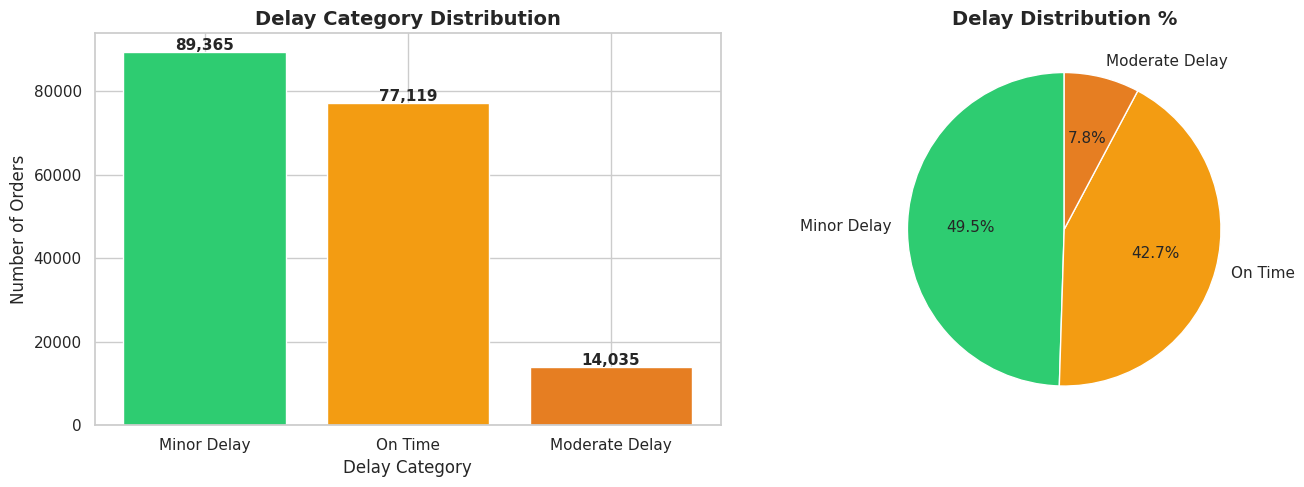

✅ Saved → visuals/01_delay_distribution.png


In [ ]:
# 2. Delay Category Distribution — Pie + Bar
delay_dist = fact_orders['delay_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[0].bar(delay_dist.index, delay_dist.values, color=colors)
axes[0].set_title('Delay Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Delay Category')
axes[0].set_ylabel('Number of Orders')
for i, v in enumerate(delay_dist.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(delay_dist.values, labels=delay_dist.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Delay Distribution %', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/01_delay_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → visuals/01_delay_distribution.png')

=== Avg Delay by Region ===
                 Avg Delay  Total Orders
Order Region                            
Central Asia          0.65           553
Central Africa        0.64          1677
South Asia            0.60          7731
Western Europe        0.60         27109
Us Center             0.59          5887
Eastern Europe        0.58          3920
East Of Usa           0.58          6915
South Of  Usa         0.58          4045
West Asia             0.57          6009
Eastern Asia          0.57          7280
East Africa           0.57          1852
West Of Usa           0.56          7993
Southeast Asia        0.56          9539
Central America       0.56         28341
South America         0.56         14935
Oceania               0.56         10148
Caribbean             0.55          8318
North Africa          0.55          3232
Northern Europe       0.55          9792
West Africa           0.55          3696
Southern Europe       0.52          9431
Southern Africa       0.48   

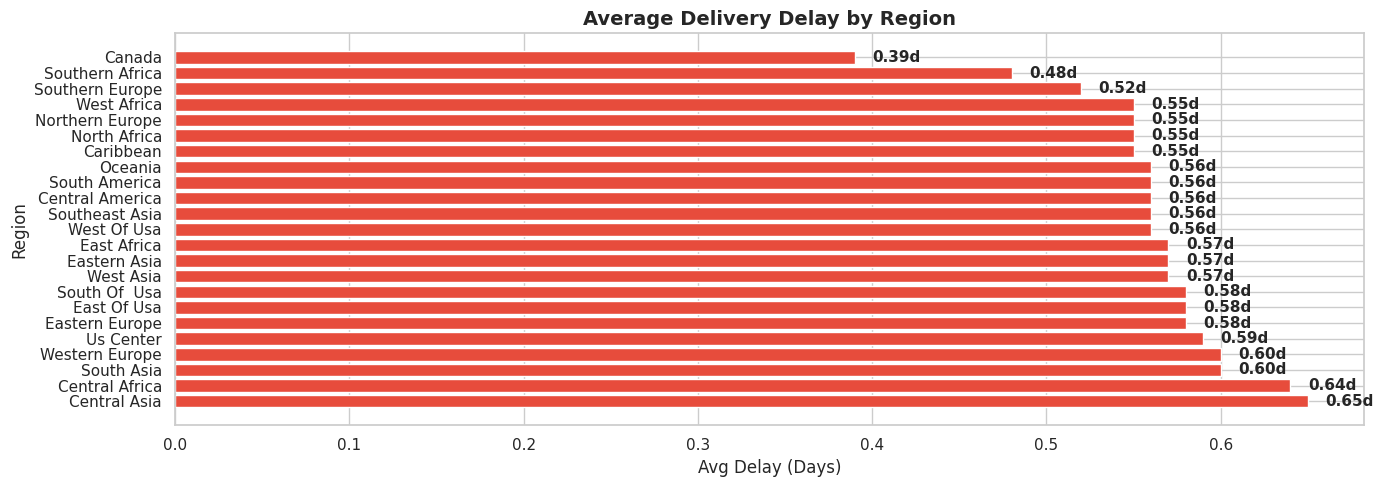

✅ Saved → visuals/02_delay_by_region.png


In [ ]:
# 3. Avg Delay by Region
region_delay = (
    fact_orders.groupby('Order Region')['delivery_delay_days']
    .agg(['mean', 'count'])
    .round(2)
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'Avg Delay', 'count': 'Total Orders'})
)
print('=== Avg Delay by Region ===')
print(region_delay)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(region_delay.index, region_delay['Avg Delay'],
               color='#e74c3c', edgecolor='white')
ax.set_title('Average Delivery Delay by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Delay (Days)')
ax.set_ylabel('Region')
for bar, val in zip(bars, region_delay['Avg Delay']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}d', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/02_delay_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → visuals/02_delay_by_region.png')

=== Delay by Shipping Mode ===
                Avg Delay  Total Orders
Shipping Mode                          
Second Class         1.99         35216
First Class          1.00         27814
Same Day             0.48          9737
Standard Class      -0.00        107752


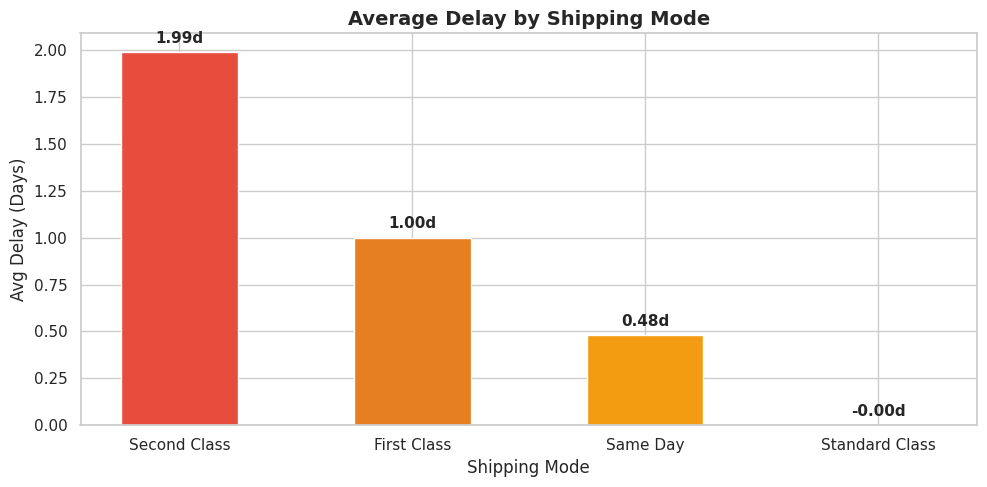

✅ Saved → visuals/03_delay_by_shipping_mode.png


In [ ]:
# 4. Delay by Shipping Mode
ship_delay = (
    fact_orders.groupby('Shipping Mode')['delivery_delay_days']
    .agg(['mean', 'count'])
    .round(2)
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'Avg Delay', 'count': 'Total Orders'})
)
print('=== Delay by Shipping Mode ===')
print(ship_delay)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71']
bars = ax.bar(ship_delay.index, ship_delay['Avg Delay'],
              color=colors, edgecolor='white', width=0.5)
ax.set_title('Average Delay by Shipping Mode', fontsize=14, fontweight='bold')
ax.set_xlabel('Shipping Mode')
ax.set_ylabel('Avg Delay (Days)')
for bar, val in zip(bars, ship_delay['Avg Delay']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.2f}d', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/03_delay_by_shipping_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → visuals/03_delay_by_shipping_mode.png')

=== Top 10 Categories by Profit ===
Category Name
Fishing                 756220.77
Cleats                  494636.92
Camping & Hiking        427455.57
Cardio Equipment        383011.10
Women'S Apparel         350421.03
Water Sports            325146.96
Indoor/Outdoor Games    318451.43
Men'S Footwear          311902.82
Shop By Sport           129813.96
Computers                69656.81
Name: Benefit per order, dtype: float64


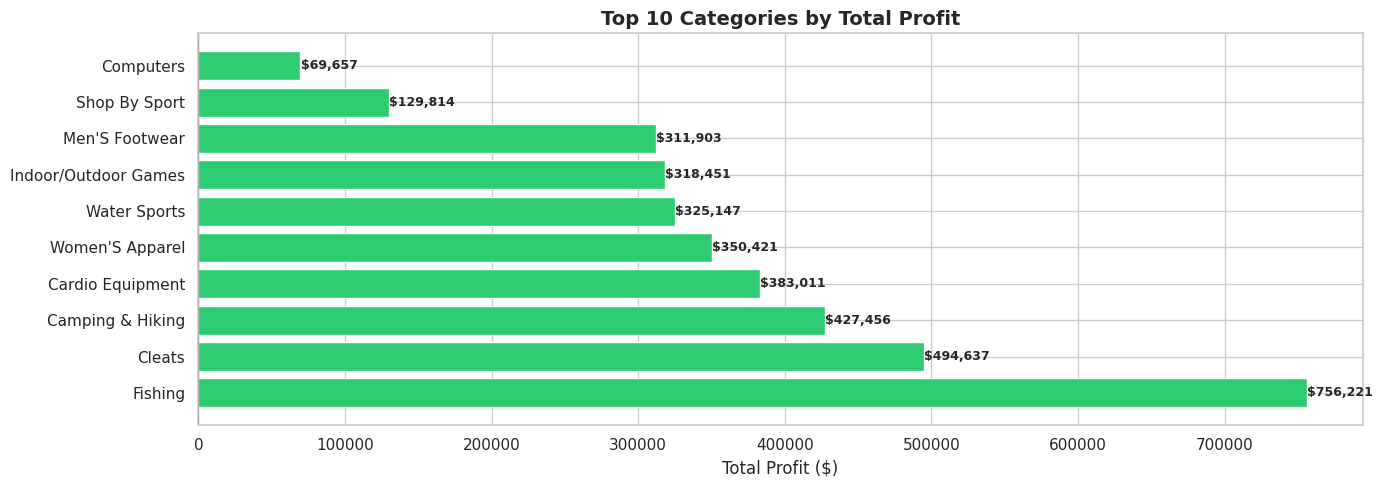

✅ Saved → visuals/04_profit_by_category.png


In [ ]:
# 5. Profit by Category (Top 10)
cat_profit = (
    fact_orders.groupby(df['Category Name'])['Benefit per order']
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .head(10)
)
print('=== Top 10 Categories by Profit ===')
print(cat_profit)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in cat_profit.values]
bars = ax.barh(cat_profit.index, cat_profit.values, color=colors)
ax.set_title('Top 10 Categories by Total Profit', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, cat_profit.values):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('visuals/04_profit_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → visuals/04_profit_by_category.png')

=== Sales by Market ===
Market
Europe          10872396.80
Latam           10277612.84
Pacific Asia     8273743.74
Usca             5066528.71
Africa           2294452.93
Name: Sales, dtype: float64


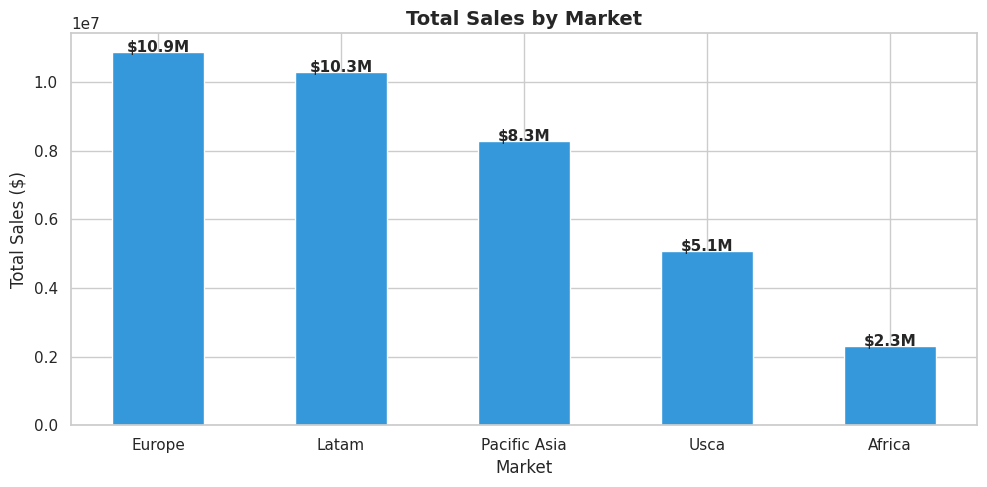

✅ Saved → visuals/05_sales_by_market.png


In [ ]:
# 6. Sales by Market
market_sales = (
    fact_orders.groupby('Market')['Sales']
    .sum()
    .round(2)
    .sort_values(ascending=False)
)
print('=== Sales by Market ===')
print(market_sales)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(market_sales.index, market_sales.values,
              color='#3498db', edgecolor='white', width=0.5)
ax.set_title('Total Sales by Market', fontsize=14, fontweight='bold')
ax.set_xlabel('Market')
ax.set_ylabel('Total Sales ($)')
for bar, val in zip(bars, market_sales.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 10000,
            f'${val/1e6:.1f}M', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/05_sales_by_market.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → visuals/05_sales_by_market.png')

=== Monthly Sales Trend ===
     period         Sales
25  2017-02  9.925349e+05
26  2017-03  1.048005e+06
27  2017-04  1.038322e+06
28  2017-05  1.105485e+06
29  2017-06  1.032086e+06
30  2017-07  1.104373e+06
31  2017-08  1.109337e+06
32  2017-09  1.143775e+06
33  2017-10  1.073994e+06
34  2017-11  6.269144e+05
35  2017-12  5.039108e+05
36  2018-01  3.316501e+05


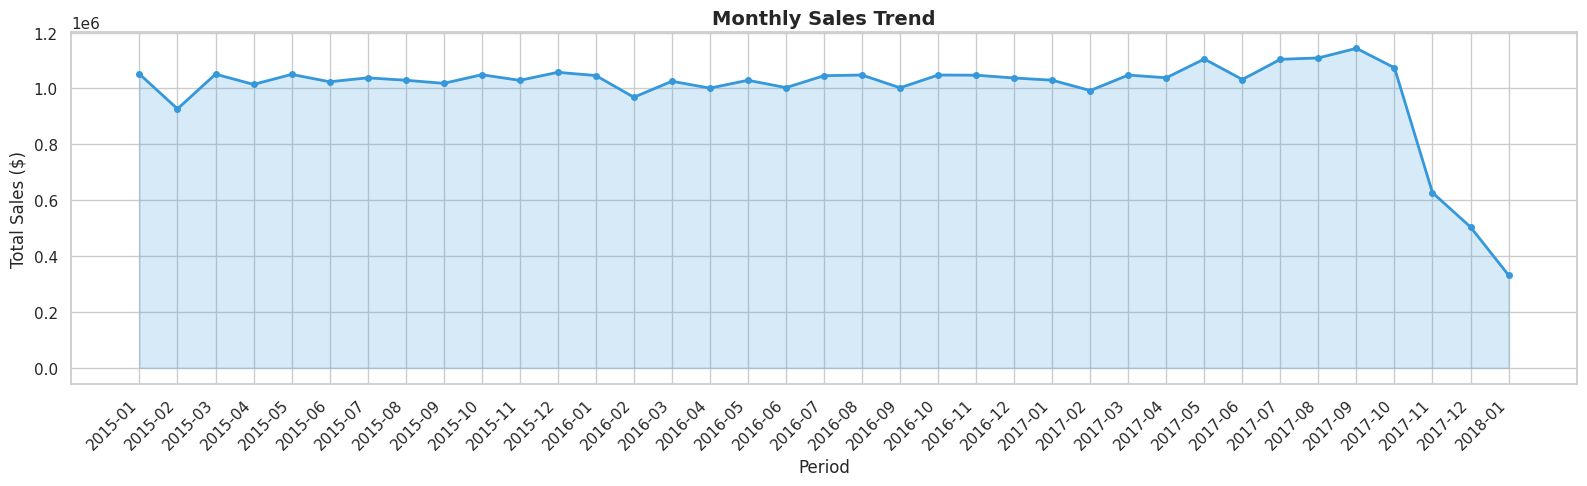

✅ Saved → visuals/06_monthly_sales_trend.png


In [ ]:
# 7. Monthly Sales Trend
monthly_sales = (
    fact_orders.groupby(['order_year', 'order_month'])['Sales']
    .sum()
    .reset_index()
    .sort_values(['order_year', 'order_month'])
)
monthly_sales['period'] = (
    monthly_sales['order_year'].astype(str) + '-' +
    monthly_sales['order_month'].astype(str).str.zfill(2)
)
print('=== Monthly Sales Trend ===')
print(monthly_sales[['period', 'Sales']].tail(12))

# Plot
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_sales['period'], monthly_sales['Sales'],
        color='#3498db', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_sales['period'], monthly_sales['Sales'],
                alpha=0.2, color='#3498db')
ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Period')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visuals/06_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → visuals/06_monthly_sales_trend.png')

=== On-Time vs Late by Shipping Mode ===
delay_category  Minor Delay  Moderate Delay  On Time
Shipping Mode                                       
First Class           27814               0        0
Same Day               4657               0     5080
Second Class          14043           14035     7138
Standard Class        42851               0    64901


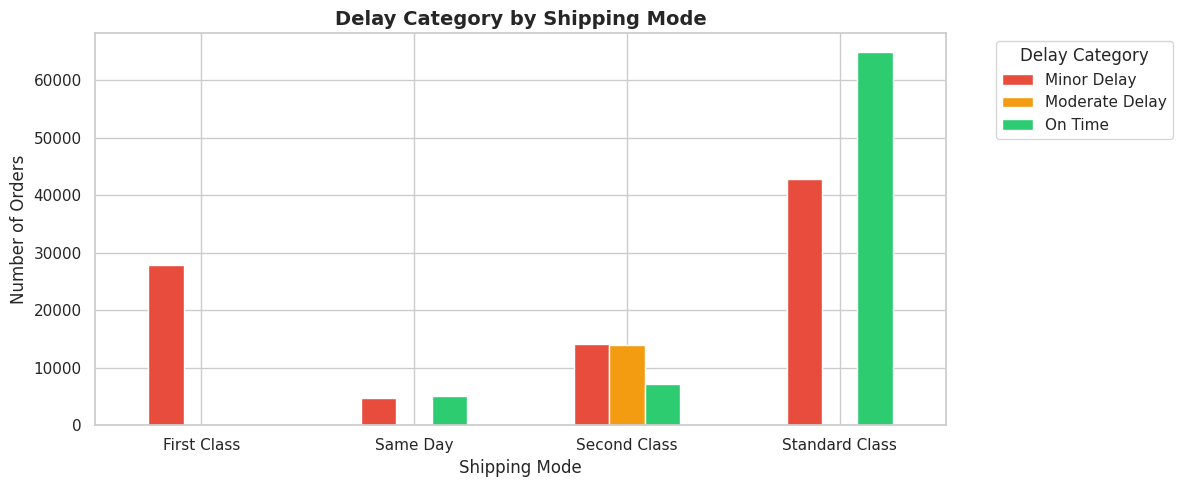

✅ Saved → visuals/07_delay_by_shipping_mode_stacked.png


In [ ]:
# 8. On-Time vs Late Orders by Shipping Mode
ontime_ship = (
    fact_orders.groupby(['Shipping Mode', 'delay_category'])
    .size()
    .unstack(fill_value=0)
)
print('=== On-Time vs Late by Shipping Mode ===')
print(ontime_ship)

# Plot
ontime_ship.plot(kind='bar', figsize=(12, 5),
                 color=['#e74c3c', '#f39c12', '#2ecc71', '#e67e22'],
                 edgecolor='white')
plt.title('Delay Category by Shipping Mode', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.legend(title='Delay Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('visuals/07_delay_by_shipping_mode_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → visuals/07_delay_by_shipping_mode_stacked.png')